In [3]:
# Imports
! pip install cptac
import cptac                     # Cancer Proteogenomic Analysis Consortium loader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px      # interactive charts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.0 MB/s eta 0:00:00
  Created wheel for sorted_nearest: filename=sorted_nearest-0.0.41-cp312-cp312-linux_x86_64.whl size=6676626 sha256=8399b8cb3d460ccd2f911df5758481164de808b951085814148235932d763970
  Stored in directory: /root/.cache/pip/wheels/7c/cb/a4/a6f831a60e479b9001be190e91000cc472addeab871957e5a9
Successfully built sorted_nearest


In [4]:
# If we focused on a single cancer type, what data can be collected?
bc = cptac.Brca() # for breast cancer...
bc.list_data_sources()
transcriptomics = bc.get_transcriptomics('broad')

In [5]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram  # Step 8 (optional)

# ------------------------------------------------------------
# CHOSEN (gene, transcript_ID) PAIRS
cols = [
    ("A1BG",     "ENST00000596924.1"),
    ("A1BG-AS1", "ENST00000593960.5"),
    ("A2M",      "ENST00000318602.12"),
    ("ZZEF1",    "ENST00000573536.1"),
]

# ------------------------------------------------------------
# BUILD FEATURE DATAFRAME (all patients × 4 transcripts) — hard coded extraction
# For each (gene, transcript) pair: select column; if a DataFrame is returned, take first column.
A1BG_col     = transcriptomics.loc[:, cols[0]]
if isinstance(A1BG_col, pd.DataFrame):
  A1BG_col = A1BG_col.iloc[:, 0]

A1BG_AS1_col = transcriptomics.loc[:, cols[1]]
if isinstance(A1BG_AS1_col, pd.DataFrame):
  A1BG_AS1_col = A1BG_AS1_col.iloc[:, 0]

A2M_col      = transcriptomics.loc[:, cols[2]]
if isinstance(A2M_col, pd.DataFrame):
  A2M_col = A2M_col.iloc[:, 0]

ZZEF1_col    = transcriptomics.loc[:, cols[3]]
if isinstance(ZZEF1_col, pd.DataFrame):
  ZZEF1_col = ZZEF1_col.iloc[:, 0]

df = pd.DataFrame({
    f"{cols[0][0]}|{cols[0][1]}": A1BG_col,
    f"{cols[1][0]}|{cols[1][1]}": A1BG_AS1_col,
    f"{cols[2][0]}|{cols[2][1]}": A2M_col,
    f"{cols[3][0]}|{cols[3][1]}": ZZEF1_col,
})

# Drop any patients with missing values in these four transcripts
df = df.dropna()

In [6]:
# 1. STANDARDIZE + PCA
X = (df - df.mean()) / df.std(ddof=0)          # standardized matrix (patients × 4)
pca = PCA()
scores = pca.fit_transform(X)                  # shape: (n_patients, <=4 PCs)
expl_var = pca.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

# Keep enough PCs to reach ≥80% cumulative variance (at least 2)
n_pc = max(2, np.searchsorted(cum_var, 0.80) + 1)
X_pcs = scores[:, :n_pc]
print(f"[1] PCA: Using first {n_pc} PCs (cumulative variance ≈ {cum_var[n_pc-1]:.1%})")


[1] PCA: Using first 3 PCs (cumulative variance ≈ 83.9%)


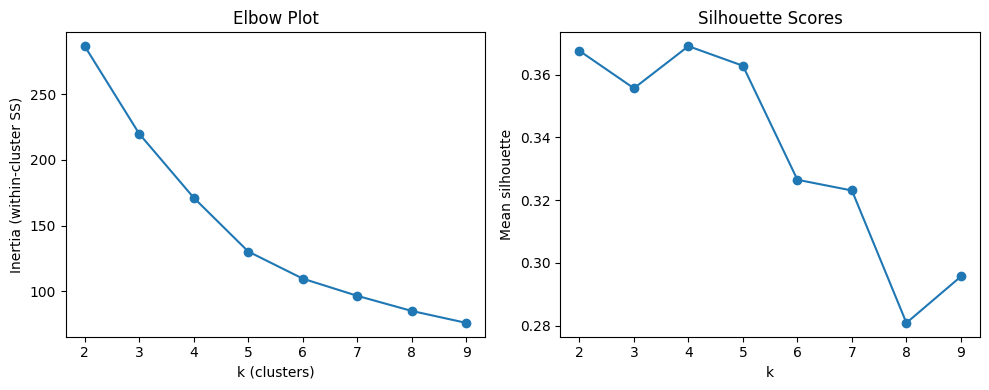

[2] Generated elbow and silhouette plots.


In [7]:
# 2. ELBOW + SILHOUETTE (k selection diagnostics)
# elbow:
  # The elbow method in k-means clustering is a visual technique to help determine the optimal number of clusters (k) for a dataset
# silhouette:
  # The silhouette value is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation)
k_values = range(2, min(10, len(X_pcs)))  # test k=2.. up to ≤9 or n_samples-1
inertias = []
sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=25, random_state=42)
    tmp_labels = km.fit_predict(X_pcs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pcs, tmp_labels))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(list(k_values), inertias, marker='o')
ax[0].set_xlabel("k (clusters)")
ax[0].set_ylabel("Inertia (within-cluster SS)")
ax[0].set_title("Elbow Plot")
ax[1].plot(list(k_values), sil_scores, marker='o')
ax[1].set_xlabel("k")
ax[1].set_ylabel("Mean silhouette")
ax[1].set_title("Silhouette Scores")
plt.tight_layout()
plt.show()
print("[2] Generated elbow and silhouette plots.")


In [8]:
# ------------------------------------------------------------
# 3. CHOOSE k (highest silhouette score)
best_k = list(k_values)[int(np.argmax(sil_scores))]
print(f"[3] Chosen k = {best_k} (silhouette = {max(sil_scores):.3f})")

kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=42)
cluster_labels = kmeans.fit_predict(X_pcs)


[3] Chosen k = 4 (silhouette = 0.369)


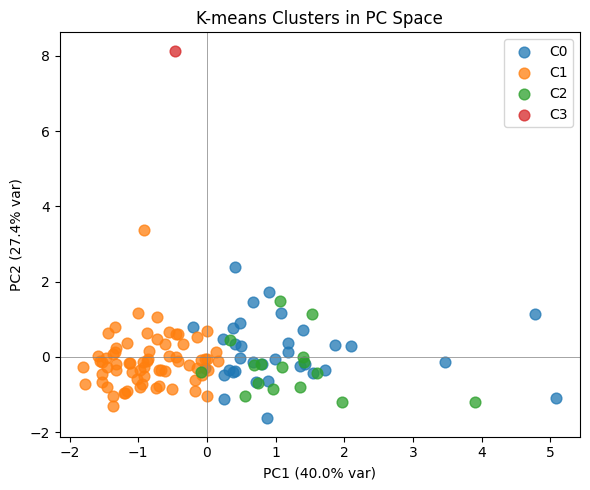

[4] Displayed clustered PC scatter plot.


In [9]:
# ------------------------------------------------------------
# 4. PC1 vs PC2 SCATTER (colored by cluster)
plt.figure(figsize=(6, 5))
for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    plt.scatter(scores[mask, 0], scores[mask, 1], s=60, alpha=0.75, label=f"C{c}")
plt.xlabel(f"PC1 ({expl_var[0]:.1%} var)")
plt.ylabel(f"PC2 ({expl_var[1]:.1%} var)")
plt.title("K-means Clusters in PC Space")
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()
print("[4] Displayed clustered PC scatter plot.")



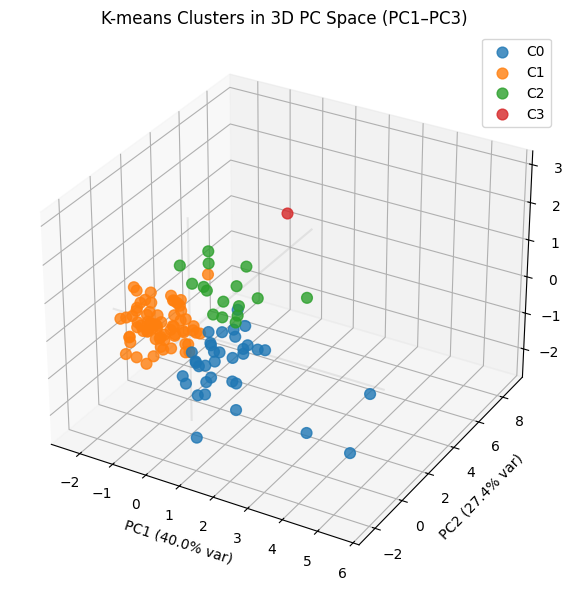

[4-3D] Displayed clustered 3D PC scatter plot.


In [10]:
# --- 3D PC1–PC2–PC3 scatter colored by cluster ---------------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

if scores.shape[1] < 3:
    raise ValueError("PC3 not available: rerun PCA keeping at least 3 components.")

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    ax.scatter(
        scores[mask, 0],   # PC1
        scores[mask, 1],   # PC2
        scores[mask, 2],   # PC3
        s=60, alpha=0.8, label=f"C{c}"
    )

ax.set_xlabel(f"PC1 ({expl_var[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({expl_var[1]:.1%} var)")
ax.set_zlabel(f"PC3 ({expl_var[2]:.1%} var)")
ax.set_title("K-means Clusters in 3D PC Space (PC1–PC3)")

# Optional: light reference planes at 0
ax.plot([0,0],[0,0],[ax.get_zlim()[0], ax.get_zlim()[1]], color='gray', alpha=0.15)
ax.plot([0,0],[ax.get_ylim()[0], ax.get_ylim()[1]],[0,0], color='gray', alpha=0.15)
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]],[0,0],[0,0], color='gray', alpha=0.15)

ax.legend()
plt.tight_layout()
plt.show()
print("[4-3D] Displayed clustered 3D PC scatter plot.")

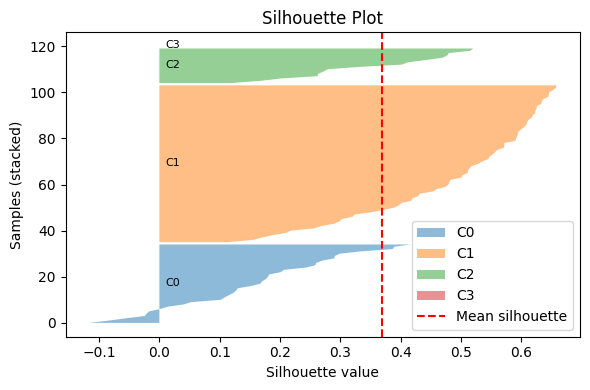

[5] Mean silhouette = 0.369


In [11]:
# optional (if time)
# 5. SILHOUETTE DISTRIBUTION PLOT
sil_vals = silhouette_samples(X_pcs, cluster_labels)
plt.figure(figsize=(6, 4))
y_lower = 0
for c in np.unique(cluster_labels):
    vals = sil_vals[cluster_labels == c]
    vals.sort()
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.5, label=f"C{c}")
    plt.text(0.01, (y_lower + y_upper)/2, f"C{c}", va="center", fontsize=8)
    y_lower = y_upper
plt.axvline(sil_vals.mean(), color="red", linestyle="--", label="Mean silhouette")
plt.xlabel("Silhouette value")
plt.ylabel("Samples (stacked)")
plt.title("Silhouette Plot")
plt.legend()
plt.tight_layout()
plt.show()
print(f"[5] Mean silhouette = {sil_vals.mean():.3f}")



In [12]:
# 6. CLUSTER CENTROIDS (in PC space)
centroids = kmeans.cluster_centers_
centroid_df = pd.DataFrame(
    centroids,
    columns=[f"PC{i+1}" for i in range(n_pc)],
    index=[f"C{c}" for c in range(best_k)]
)
print("[6] Centroids (first PCs):")
display(centroid_df)



[6] Centroids (first PCs):


,PC1,PC2,PC3
C0,1.113552,0.128385,-0.678787
C1,-0.837975,-0.119186,-0.002671
C2,1.206708,-0.275274,1.460822
C3,-0.461340,8.134780,0.568675


[7] Standardized per-cluster means:


,A1BG|ENST00000596924.1,A1BG-AS1|ENST00000593960.5,A2M|ENST00000318602.12,ZZEF1|ENST00000573536.1
_cluster,,,,
0,0.116625,0.993391,0.108236,0.839913
1,-0.495804,-0.481441,-0.152090,-0.467893
2,1.905410,-0.029879,-0.124774,0.162081
3,-0.357947,-1.071164,8.702326,0.294349


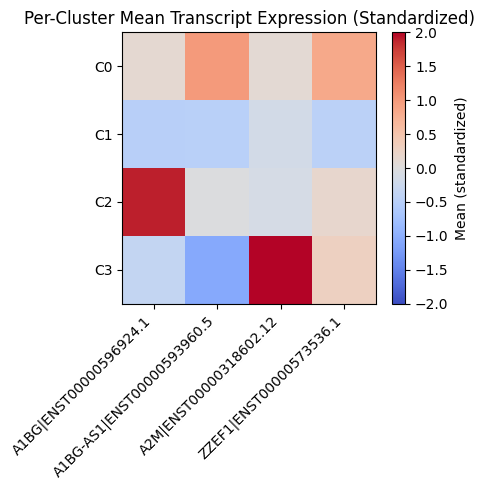


Cluster 0 transcripts sorted (descending):
A1BG-AS1|ENST00000593960.5    0.993391
ZZEF1|ENST00000573536.1       0.839913
A1BG|ENST00000596924.1        0.116625
A2M|ENST00000318602.12        0.108236
Name: 0, dtype: float64

Cluster 1 transcripts sorted (descending):
A2M|ENST00000318602.12       -0.152090
ZZEF1|ENST00000573536.1      -0.467893
A1BG-AS1|ENST00000593960.5   -0.481441
A1BG|ENST00000596924.1       -0.495804
Name: 1, dtype: float64

Cluster 2 transcripts sorted (descending):
A1BG|ENST00000596924.1        1.905410
ZZEF1|ENST00000573536.1       0.162081
A1BG-AS1|ENST00000593960.5   -0.029879
A2M|ENST00000318602.12       -0.124774
Name: 2, dtype: float64

Cluster 3 transcripts sorted (descending):
A2M|ENST00000318602.12        8.702326
ZZEF1|ENST00000573536.1       0.294349
A1BG|ENST00000596924.1       -0.357947
A1BG-AS1|ENST00000593960.5   -1.071164
Name: 3, dtype: float64


In [13]:
# 7. PER-CLUSTER FEATURE MEANS (standardized) + heatmap
cluster_means = (
    pd.DataFrame(X, index=df.index, columns=df.columns)
      .assign(_cluster=cluster_labels)
      .groupby("_cluster").mean()
      .sort_index()
)

print("[7] Standardized per-cluster means:")
display(cluster_means)

plt.figure(figsize=(len(df.columns)*1.2, 1.0*best_k + 1))
plt.imshow(cluster_means.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
plt.colorbar(label="Mean (standardized)")
plt.yticks(range(best_k), [f"C{c}" for c in cluster_means.index])
plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
plt.title("Per-Cluster Mean Transcript Expression (Standardized)")
plt.tight_layout()
plt.show()

for c in cluster_means.index:
    print(f"\nCluster {c} transcripts sorted (descending):")
    print(cluster_means.loc[c].sort_values(ascending=False))
